# Lab: Tic-Tac-Toe with Artificial Intelligence  

In this lab, we will create the classic **Tic-Tac-Toe** game using Python and Google Colab. More importantly, we will learn how to implement an **Artificial Intelligence (AI)** strategy that plays against us using the **Minimax algorithm**.  

### What will you learn?  
- How to draw the game board.  
- How to check moves and determine the winner.  
- What the **Minimax** algorithm is and how it helps AI make optimal decisions.  
- How AI functions in a simple game and how it can make better decisions than a human player.

## **Tic-Tac-Toe on a 3x3 Board:**  

In this section, we will see an implementation of the Minimax algorithm on a 3x3 board.

In [2]:
#@title Import neccesary libraries
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# @title Drawing the Game Board

def print_board(board):
    fig, ax = plt.subplots(figsize=(6, 6))  # Create a 6x6 figure for the game board.

    # Draw the game grid (horizontal and vertical lines).
    ax.set_xticks(np.arange(0, 3, 1))
    ax.set_yticks(np.arange(0, 3, 1))
    ax.grid(True, color='black', linewidth=2)  # Set the grid lines to be black and thick.

    # Hide axis ticks and labels.
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Set the background to white.
    ax.set_facecolor('white')

    # Display X's and O's on the game board.
    for i in range(3):
        for j in range(3):
            if board[i][j] == "X":
                ax.text(j + 0.5, i + 0.5, "X", ha='center', va='center', fontsize=50, color="red", weight='bold')
            elif board[i][j] == "O":
                ax.text(j + 0.5, i + 0.5, "O", ha='center', va='center', fontsize=50, color="blue", weight='bold')

    # Set grid limits.
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    plt.gca().invert_yaxis()  # Invert the y-axis to match matrix coordinates.

    # Display the game board.
    plt.show()


In [5]:
# @title Rules Implementation

def is_valid_move(board, row, col):
    return board[row][col] == " "  # Check if the cell is empty.

def make_move(board, row, col, player):
    if is_valid_move(board, row, col):
        board[row][col] = player  # Place the player's symbol in the selected cell.
        return True
    return False

def check_win(board, player):
    # Check rows
    for row in board:
        if all([cell == player for cell in row]):
            return True

    # Check columns
    for col in range(3):
        if all([board[row][col] == player for row in range(3)]):
            return True

    # Check diagonals
    if all([board[i][i] == player for i in range(3)]) or all([board[i][2 - i] == player for i in range(3)]):
        return True

    return False

def is_draw(board):
    return all([cell != " " for row in board for cell in row])  # Check if all cells are filled.


In [6]:
# @title Minimax Implementation

def minimax(board, depth, is_maximizing):
    if check_win(board, "X"):
        return -1  # Player X wins, so negative score for AI.
    if check_win(board, "O"):
        return 1  # AI wins, so positive score.
    if is_draw(board):
        return 0  # Draw.

    if is_maximizing:
        best_score = -float("inf")
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "O"  # AI makes the move.
                    score = minimax(board, depth + 1, False)
                    board[row][col] = " "
                    best_score = max(score, best_score)
        return best_score
    else:
        best_score = float("inf")
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "X"  # Player makes the move.
                    score = minimax(board, depth + 1, True)
                    board[row][col] = " "
                    best_score = min(score, best_score)
        return best_score

def find_best_move(board):
    best_move = None
    best_score = -float("inf")
    for row in range(3):
        for col in range(3):
            if board[row][col] == " ":
                board[row][col] = "O"
                score = minimax(board, 0, False)
                board[row][col] = " "
                if score > best_score:
                    best_score = score
                    best_move = (row, col)
    return best_move


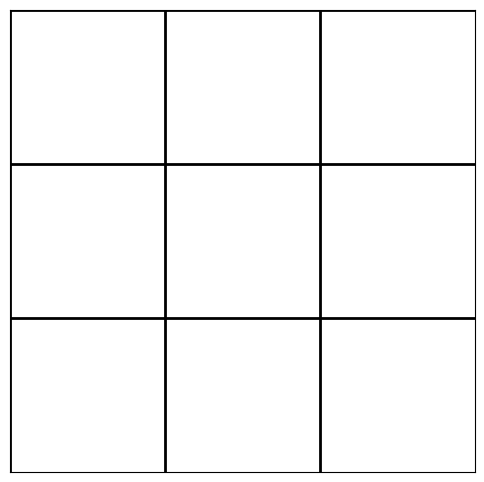

In [ ]:
# @title Game Simulator

board = [[" ", " ", " "],
         [" ", " ", " "],
         [" ", " ", " "]]

while True:
    print_board(board)  # Display the game board

    if check_win(board, "X"):  # Check if player X has won
        print("X has won!")
        break
    if check_win(board, "O"):  # Check if AI (O) has won
        print("O has won!")
        break
    if is_draw(board):  # Check if the game is a draw
        print("It's a draw!")
        break

    # Player's turn
    while True:
        try:
            # Ask for the player's move (row and column, separated by space)
            row, col = map(int, input("Enter your move (row and column, separated by space): ").split())
            if 0 <= row < 3 and 0 <= col < 3:  # Check if the move is within the board's limits
                if make_move(board, row, col, "X"):  # Make the move for player X
                    break
                else:
                    print("This spot is already taken. Try again.")
            else:
                print("Invalid input. Enter row and column numbers between 0 and 2.")
        except ValueError:
            print("Invalid input. Please enter two integers separated by space.")

    # AI's turn
    ai_move = find_best_move(board)  # AI chooses the best move
    if ai_move:
        make_move(board, ai_move[0], ai_move[1], "O")  # AI makes the move for O


## Further Work - Tic-Tac-Toe on a 6x6 Board  

Earlier, we observed that for very large game boards, the space required to explore all possible game outcomes grows exponentially. This time, we are also changing the winning rule: a player must align **4 consecutive symbols** (either diagonally, in a row, or in a column) to win.  

On a **6x6** board, the Minimax algorithm may not be able to analyze all possible game endings to choose the best move. In this context, it is necessary to **limit the search depth**, for example, to **2 levels**, and use an **evaluation function** for non-terminal positions.  

### In this part of the lab, you will:  
- **Implement** your own `minimax` function for a 6x6 board (**Problem 1**).  
- **Present Ideas for Heuristic Functions** To improve the performance of your algorithm, it is essential to define heuristic functions that evaluate non-terminal board positions. These functions will help the algorithm decide which positions are better than others, even when search depth is limited (**Problem 2**).  
- **Implement** a heuristic evaluation function called `analyze_board(board, is_maximizing)` so that your AI algorithm becomes more intelligent (**Problem 8**).  


In [ ]:
# @title Logic for 6x6 Board: Display the board, check win and draw conditions

def print_board(board):
    fig, ax = plt.subplots(figsize=(6, 6))  # Create a 6x6 figure for the game board.

    # Draw the game grid (horizontal and vertical lines).
    ax.set_xticks(np.arange(0, 6, 1))
    ax.set_yticks(np.arange(0, 6, 1))
    ax.grid(True, color='black', linewidth=2)  # Set the grid lines to be black and thick.

    # Hide the axis ticks and labels.
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Set the background to white.
    ax.set_facecolor('white')

    # Display X's and O's on the game board.
    for i in range(6):
        for j in range(6):
            if board[i][j] == "X":
                ax.text(j + 0.5, i + 0.5, "X", ha='center', va='center', fontsize=50, color="red", weight='bold')
            elif board[i][j] == "O":
                ax.text(j + 0.5, i + 0.5, "O", ha='center', va='center', fontsize=50, color="blue", weight='bold')

    # Set the grid limits.
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    plt.gca().invert_yaxis()  # Invert the y-axis to match the matrix coordinates.

    # Display the game board.
    plt.show()



def check_win(board, player):
    n = len(board)  # Board size (in this case, 6)
    win_condition = 4  # Number of consecutive symbols needed to win

    # Check rows
    for row in range(n):
        for col in range(n - win_condition + 1):
            if all([board[row][col + i] == player for i in range(win_condition)]):
                return True

    # Check columns
    for col in range(n):
        for row in range(n - win_condition + 1):
            if all([board[row + i][col] == player for i in range(win_condition)]):
                return True

    # Check diagonals (top-left to bottom-right)
    for row in range(n - win_condition + 1):
        for col in range(n - win_condition + 1):
            if all([board[row + i][col + i] == player for i in range(win_condition)]):
                return True

    # Check diagonals (top-right to bottom-left)
    for row in range(n - win_condition + 1):
        for col in range(win_condition - 1, n):
            if all([board[row + i][col - i] == player for i in range(win_condition)]):
                return True

    return False

def is_draw(board):
    # Check if all positions are filled
    return all([cell != " " for row in board for cell in row])


### ✏️ **Problem 1:**  

The code below represents a `minimax` function, but it contains some errors. Correct these errors based on the correct example of the `minimax` algorithm presented in first Part.  

To fix the function:  

- **Ensure the algorithm follows the classic `minimax` rules**: The algorithm should maximize the score for the current player and minimize the score for the opponent.  

- **Fix possible errors related to recursion and limited depth handling**: Make sure the search depth is managed correctly and that the `minimax` function is called properly for each move.  

- **Other errors**: Ensure the board size is correct and that the indices used to check specific board characteristics are accurate.

In [ ]:
# @title ✏️ Minimax Implementation for 6x6 Board
import math

# DO NOT CHANGE ANYTHING IN THIS SECTION
def analyze_board_0(board, is_maximizing):
  return 0

def minimax_6x6(board, depth, is_maximizing, analyze_board):
    if check_win(board, "X"):
        return -10000  # Player X wins, so negative score for AI.
    if check_win(board, "O"):
        return 10000  # AI wins, so positive score.
    if is_draw(board):
        return 0  # Draw.
    if depth > 2:
        return analyze_board(board, is_maximizing)
# DO NOT CHANGE ANYTHING IN THIS SECTION

# FIX ERRORS IN THIS SECTION
    if is_maximizing:
        best_score = -float("inf")
        for row in range(8):
            for col in range(8):
                if board[row][col] == " ":
                    board[row][col] = "O"  # AI makes the move.
                    score = minimax_6x6(board, depth - 1, False, analyze_board)
                    board[row][col-1] = " "
                    best_score = min(score, best_score)
        return best_score
    else:
        best_score = float("inf")
        for row in range(6):
            for col in range(6):
                if board[row][col] == " ":
                    board[row][col] = "X"  # Player makes the move.
                    score = minimax_6x6(board, depth + 1, True, analyze_board)
                    board[row][col] = " "
                    best_score = min(score, best_score)
        return best_score
# FIX ERRORS IN THIS SECTION

# DO NOT CHANGE ANYTHING IN THIS SECTION
def find_best_move(board, analyze_board):
    best_move = None
    best_score = -float("inf")
    for row in range(6):
        for col in range(6):
            if board[row][col] == " ":
                board[row][col] = "O"
                score = minimax_6x6(board, 0, False, analyze_board)
                board[row][col] = " "
                if score > best_score:
                    best_score = score
                    best_move = (row, col)
    return best_move
# DO NOT CHANGE ANYTHING IN THIS SECTION


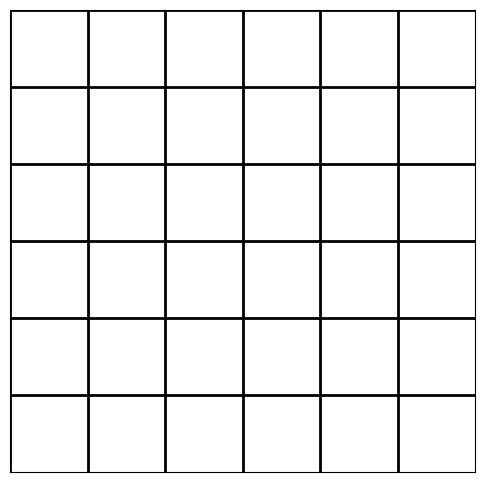

Introduceți mutarea dvs. (rând și coloană, separate prin spațiu): 3 3


IndexError: list index out of range

In [ ]:
# @title Game Simulation

board = [[" " for _ in range(6)] for _ in range(6)]


while True:
    print_board(board)  # Display the game board

    if check_win(board, "X"):  # Check if player X has won
        print("X has won!")
        break
    if check_win(board, "O"):  # Check if AI (O) has won
        print("O has won!")
        break
    if is_draw(board):  # Check if the game ended in a draw
        print("It's a draw!")
        break

    # Player's turn
    while True:
        try:
            # Ask for the player's move (row and column, separated by space)
            row, col = map(int, input("Enter your move (row and column, separated by space): ").split())
            if 0 <= row < 6 and 0 <= col < 6:  # Check if the move is within board limits
                if make_move(board, row, col, "X"):  # Make the move for player X
                    break
                else:
                    print("This spot is already occupied. Try again.")
            else:
                print("Invalid input. Enter row and column numbers between 0 and 5.")
        except ValueError:
            print("Invalid input. Please enter two integers separated by space.")

    # AI's turn
    ai_move = find_best_move(board, analyze_board_0)  # AI chooses the best move
    if ai_move:
        make_move(board, ai_move[0], ai_move[1], "O")  # AI makes the move for O


### ✏️ **Problem 2:**

Provide 3 examples of the function `evaluate_board(board, is_maximizing)` that we could use to improve the performance of our AI model. These functions are meant to evaluate board positions in a way that helps make more informed decisions within the `minimax` algorithm. It’s important to note that the evaluated positions are not the final positions of the game, but intermediate ones.

**Example:** Evaluation Based on Proximity to Winning
   - **Description:** Evaluates how close each player is to winning based on the number of aligned symbols on all lines.
   - **Pseudocode:**
     ```
     FUNCTION analyze_board(board, is_maximizing)
         score = 0
         FOR EACH line IN all_lines
             x_count = COUNT_OF("X" IN line)
             o_count = COUNT_OF("O" IN line)
             IF x_count == 3:
                 score = score + 50  // X is close to winning
             ELSE IF o_count == 3:
                 score = score - 50  // O is close to winning
         RETURN score
     ```



### ✏️ **Problem 9:**
Code one of the proposed ideas! Then, check how intelligent your model is! Be careful about how the `is_maximizing` function is generally used.

In [ ]:
import math

def analise_board(board, is_maximizing):
  ### your code here

  ### your code here
  return 0


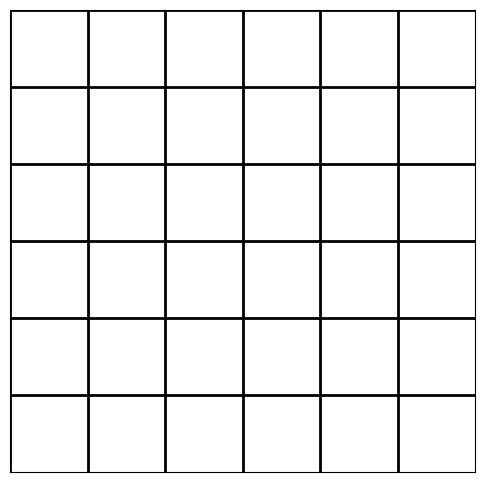

Introduceți mutarea dvs. (rând și coloană, separate prin spațiu): 3 3


IndexError: list index out of range

In [ ]:
board = [[" " for _ in range(6)] for _ in range(6)]

while True:
    print_board(board)  # Displays the game board

    if check_win(board, "X"):  # Checks if player X has won
        print("X has won!")
        break
    if check_win(board, "O"):  # Checks if AI (O) has won
        print("O has won!")
        break
    if is_draw(board):  # Checks if the game has ended in a draw
        print("It's a draw!")
        break

    # Player's turn
    while True:
        try:
            # Prompts the player for their move (row and column, separated by space)
            row, col = map(int, input("Enter your move (row and column, separated by space): ").split())
            if 0 <= row < 7 and 0 <= col < 7:  # Checks if the move is within board limits
                if make_move(board, row, col, "X"):  # Executes the move for player X
                    break
                else:
                    print("This spot is already occupied. Try again.")
            else:
                print("Invalid input. Enter row and column numbers between 0 and 6.")
        except ValueError:
            print("Invalid input. Please enter two integers separated by space.")

    # AI's turn
    ai_move = find_best_move(board, analise_board)  # AI selects the best move
    if ai_move:
        make_move(board, ai_move[0], ai_move[1], "O")  # AI makes the move for O
